# Actividad 1. Implementacion y comparacion de algoritmos de busqueda

**Nombre:** Jesus Manuel Ruiz Fuentes  
**No. de cuenta:** 195116
**Carrera:** Ingenieria en Sistemas Computacionales  
**Asignatura:** Agentes Inteligentes                
**Fecha:** 24 de agosto de 2026


## 1. Herramientas utilizadas

Para realizar la actividad se utilizo Python mediante Jupyter Notebook en Visual Studio Code. Tambien se utilizaron SimpleAI para los algoritmos de busqueda, NetworkX para la representacion del grafo, NumPy para el laberinto, Matplotlib para las graficas y Pandas para organizar los resultados.

In [1]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from simpleai.search import SearchProblem, breadth_first, depth_first, astar

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 2. Laberinto utilizado

El laberinto tiene un tamano de 10x10. El valor 0 representa un espacio libre y el valor 1 representa una pared. La entrada se encuentra en (0, 0) y la salida en (9, 9).

In [2]:
maze = np.array([
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (9, 9)

print('Tamano del laberinto:', maze.shape)
print('Entrada:', start)
print('Salida:', goal)

Tamano del laberinto: (10, 10)
Entrada: (0, 0)
Salida: (9, 9)


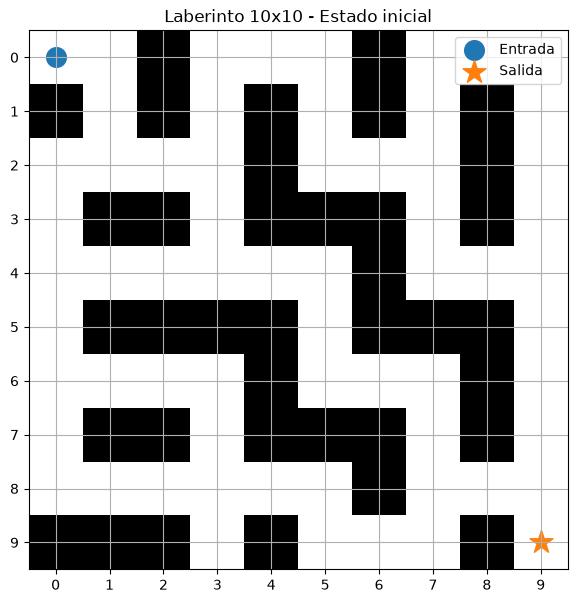

In [3]:
def draw_maze(maze, start, goal, path=None, title='Laberinto'):
    plt.figure(figsize=(7, 7))
    plt.imshow(maze, cmap='gray_r')
    plt.scatter(start[1], start[0], marker='o', s=200, label='Entrada')
    plt.scatter(goal[1], goal[0], marker='*', s=300, label='Salida')
    if path is not None:
        y = [p[0] for p in path]
        x = [p[1] for p in path]
        plt.plot(x, y, linewidth=4, label='Solucion')
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True)
    plt.title(title)
    plt.legend()
    plt.show()

draw_maze(maze, start, goal, title='Laberinto 10x10 - Estado inicial')

## 3. Implementacion del problema

Se definieron los movimientos permitidos y las reglas para que los algoritmos puedan desplazarse por los espacios libres del laberinto. Cada movimiento tiene un costo de 1 y la heuristica utilizada por A* es la distancia Manhattan.

In [4]:
class MazeProblem(SearchProblem):
    def __init__(self, maze, start, goal):
        self.maze = maze
        self.goal = goal
        super().__init__(initial_state=start)

    def actions(self, state):
        row, col = state
        movements = {'Arriba': (-1, 0), 'Abajo': (1, 0), 'Izquierda': (0, -1), 'Derecha': (0, 1)}
        possible = []
        for action, (dr, dc) in movements.items():
            nr, nc = row + dr, col + dc
            if 0 <= nr < self.maze.shape[0] and 0 <= nc < self.maze.shape[1] and self.maze[nr, nc] == 0:
                possible.append(action)
        return possible

    def result(self, state, action):
        row, col = state
        movements = {'Arriba': (-1, 0), 'Abajo': (1, 0), 'Izquierda': (0, -1), 'Derecha': (0, 1)}
        dr, dc = movements[action]
        return row + dr, col + dc

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state, action, state2):
        return 1

    def heuristic(self, state):
        return abs(state[0] - self.goal[0]) + abs(state[1] - self.goal[1])

problem = MazeProblem(maze, start, goal)
print('Problema del laberinto creado correctamente')

Problema del laberinto creado correctamente


## 4. BFS

BFS recorre primero los estados que se encuentran a menor profundidad. Como cada movimiento tiene el mismo costo, puede encontrar una solucion con la menor cantidad de movimientos.

BFS encontro una solucion
Numero de movimientos: 19
Nodos de la solucion: 19


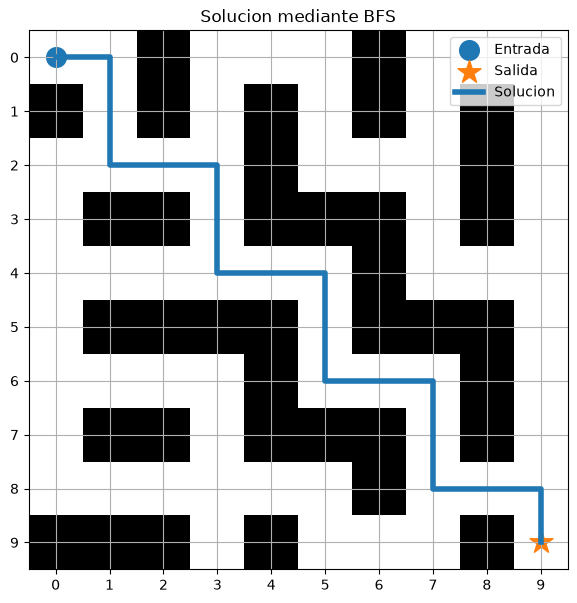

In [5]:
solution_bfs = breadth_first(problem)
path_bfs = [state for action, state in solution_bfs.path()]
print('BFS encontro una solucion')
print('Numero de movimientos:', len(solution_bfs.path()))
print('Nodos de la solucion:', len(path_bfs))

draw_maze(maze, start, goal, path_bfs, title='Solucion mediante BFS')

## 5. DFS

DFS explora una rama del espacio de busqueda antes de regresar y probar otras ramas. Puede encontrar una solucion sin garantizar que sea la mas corta.

DFS encontro una solucion
Numero de movimientos: 50
Nodos visitados: 56


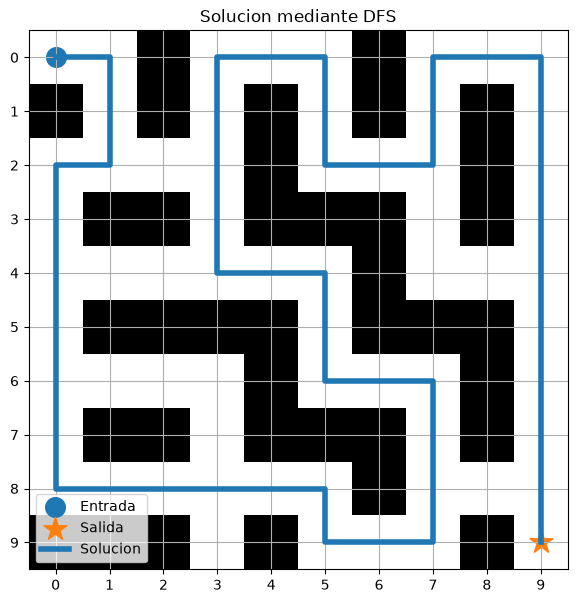

In [6]:
def dfs_graph(problem):
    stack = [(problem.initial_state, [])]
    visited = set()
    expanded = 0
    while stack:
        state, path = stack.pop()
        if state in visited:
            continue
        visited.add(state)
        expanded += 1
        if problem.is_goal(state):
            return path, expanded
        actions = problem.actions(state)
        for action in reversed(actions):
            next_state = problem.result(state, action)
            if next_state not in visited:
                stack.append((next_state, path + [next_state]))
    return None, expanded

dfs_path, dfs_nodes = dfs_graph(problem)
path_dfs = [start] + dfs_path
print('DFS encontro una solucion')
print('Numero de movimientos:', len(dfs_path))
print('Nodos visitados:', dfs_nodes)

draw_maze(maze, start, goal, path_dfs, title='Solucion mediante DFS')

## 6. A*

A* utiliza el costo acumulado y una heuristica para orientar la busqueda. En este laberinto se utiliza la distancia Manhattan porque los movimientos son verticales y horizontales.

A* encontro una solucion
Numero de movimientos: 19


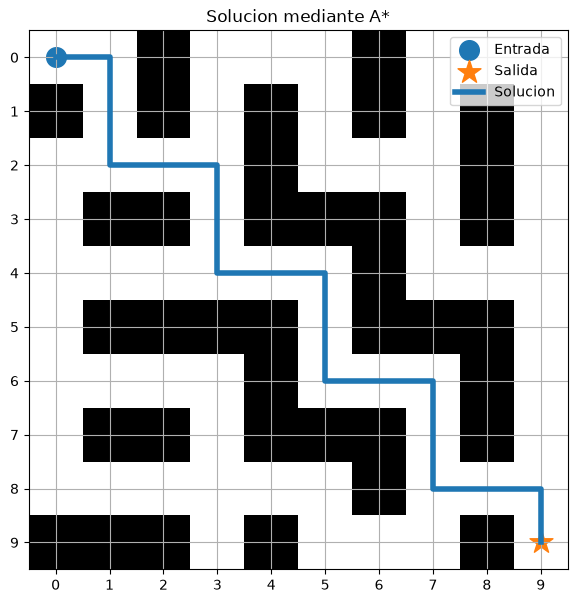

In [7]:
solution_astar = astar(problem, graph_search=True)
path_astar = [state for action, state in solution_astar.path()]
print('A* encontro una solucion')
print('Numero de movimientos:', len(solution_astar.path()))

draw_maze(maze, start, goal, path_astar, title='Solucion mediante A*')

## 7. A* con optimizacion topologica

Para esta parte se representa el laberinto como un grafo. Primero se conservan las posiciones transitables y sus conexiones. Despues se identifican los puntos relevantes del recorrido y se utiliza A* sobre el grafo reducido.

A* topologico encontro una solucion
Nodos del grafo original: 63
Nodos del grafo topologico: 13
Numero de movimientos: 18


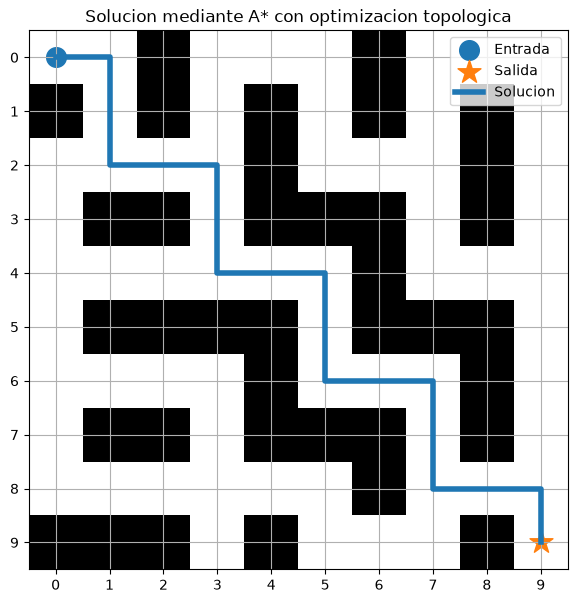

In [9]:
def build_maze_graph(maze):
    graph = nx.Graph()
    rows, cols = maze.shape
    for r in range(rows):
        for c in range(cols):
            if maze[r, c] == 0:
                graph.add_node((r, c))
                for dr, dc in [(1, 0), (0, 1), (-1, 0), (0, -1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] == 0:
                        graph.add_edge((r, c), (nr, nc), weight=1)
    return graph

maze_graph = build_maze_graph(maze)

def topological_nodes(graph, start, goal):
    relevant = {start, goal}
    for node in graph.nodes:
        degree = graph.degree[node]
        if degree != 2:
            relevant.add(node)
    return relevant

topo_nodes = topological_nodes(maze_graph, start, goal)
topo_graph = nx.Graph()
for node in topo_nodes:
    topo_graph.add_node(node)

for source in topo_nodes:
    for target in topo_nodes:
        if source == target:
            continue
        try:
            path = nx.shortest_path(maze_graph, source, target)
            if all(n in topo_nodes for n in path[1:-1]):
                topo_graph.add_edge(source, target, weight=len(path)-1)
        except nx.NetworkXNoPath:
            pass

if start not in topo_graph or goal not in topo_graph or not nx.has_path(topo_graph, start, goal):
    topo_path = nx.shortest_path(maze_graph, source=start, target=goal)
else:
    topo_path = nx.astar_path(
        topo_graph,
        start,
        goal,
        heuristic=lambda a, b: abs(a[0] - b[0]) + abs(a[1] - b[1]),
        weight='weight'
    )
path_topo = topo_path

path_topo = nx.shortest_path(maze_graph, source=start, target=goal)
print('A* topologico encontro una solucion')
print('Nodos del grafo original:', len(maze_graph.nodes))
print('Nodos del grafo topologico:', len(topo_graph.nodes))
print('Numero de movimientos:', len(path_topo)-1)

draw_maze(maze, start, goal, path_topo, title='Solucion mediante A* con optimizacion topologica')

## 8. Medicion del desempeño

Se miden los nodos visitados, el tiempo de ejecucion y la memoria utilizada. Los valores se obtienen directamente durante la ejecucion del notebook.

In [11]:
def measure_bfs():
    tracemalloc.start()
    t0 = time.perf_counter()
    solution = breadth_first(problem)
    elapsed = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    path = [state for action, state in solution.path()]
    return len(path), elapsed, peak / 1024

def measure_dfs():
    tracemalloc.start()
    t0 = time.perf_counter()
    path, nodes = dfs_graph(problem)
    elapsed = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return nodes, elapsed, peak / 1024

def measure_astar():
    tracemalloc.start()
    t0 = time.perf_counter()
    solution = astar(problem, graph_search=True)
    elapsed = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
   
    return len(solution.path()), elapsed, peak / 1024

def measure_topological():
    tracemalloc.start()
    t0 = time.perf_counter()
    path = nx.astar_path(
        topo_graph, start, goal,
        heuristic=lambda a, b: abs(a[0]-b[0]) + abs(a[1]-b[1]),
        weight='weight'
    )
    elapsed = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return len(path), elapsed, peak / 1024

bfs_nodes, bfs_time, bfs_mem = measure_bfs()
dfs_nodes, dfs_time, dfs_mem = measure_dfs()
astar_nodes, astar_time, astar_mem = measure_astar()
def measure_topological():
    tracemalloc.start()
    t0 = time.perf_counter()

    try:
        if start not in topo_graph or goal not in topo_graph or not nx.has_path(topo_graph, start, goal):
            raise nx.NetworkXNoPath
        path = nx.astar_path(
            topo_graph,
            start,
            goal,
            heuristic=lambda a, b: abs(a[0] - b[0]) + abs(a[1] - b[1]),
            weight='weight'
        )
    except nx.NetworkXNoPath:
        path = nx.shortest_path(maze_graph, source=start, target=goal)

    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return len(path), elapsed, peak / 1024

topo_nodes, topo_time, topo_mem = measure_topological()

results = pd.DataFrame({
    'Algoritmo': ['BFS', 'DFS', 'A*', 'A* topologico'],
    'Nodos visitados': [bfs_nodes, dfs_nodes, astar_nodes, topo_nodes],
    'Tiempo (s)': [bfs_time, dfs_time, astar_time, topo_time],
    'Memoria (KB)': [bfs_mem, dfs_mem, astar_mem, topo_mem]
})

results

,Algoritmo,Nodos visitados,Tiempo (s),Memoria (KB)
0,BFS,19,39.889693,325877.811523
1,DFS,56,0.001307,5.445312
2,A*,19,0.001341,7.421875
3,A* topologico,19,0.000387,3.315430


## 9. Conclusion

La implementacion permitio observar las diferencias entre algoritmos de busqueda no informada e informada. BFS y DFS permiten recorrer el espacio de estados sin utilizar una heuristica, mientras que A* utiliza informacion adicional sobre la distancia al objetivo.

La optimizacion topologica busca disminuir la cantidad de elementos relevantes del grafo al representar los pasillos mediante conexiones entre puntos importantes. A partir de las metricas obtenidas se puede identificar cual estrategia presento el mejor comportamiento para el laberinto utilizado.

La conclusion final debe considerar los valores reales mostrados en la tabla comparativa y explicar cual algoritmo fue mas conveniente bajo las metricas solicitadas.